# Test-only Renderer 樣式範例

Runtime：`phase6.2-v3`  
產生時間（UTC）：`2026-07-26T07:10:34+00:00`  
所有 payload 都是固定、領域無關的離線資料。

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "LLM_as_a_Judge").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "LLM_as_a_Judge").exists():
    raise RuntimeError("找不到 BadmintonAI 專案根目錄")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from LLM_as_a_Judge.test_output_runtime import (
    RUNTIME_VERSION,
    ChartSeries,
    CompositeItem,
    CompositeResult,
    HeatmapPoints,
    ScalarResult,
    TableResult,
    render_bar,
    render_composite,
    render_heatmap,
    render_line,
    render_pie,
    render_scatter,
    render_table,
    render_text,
)

print(f"Renderer version: {RUNTIME_VERSION}")

Renderer version: phase6.2-v3


## Text／Scalar

適合單一數值、單位與簡短註記；不強迫產生表格或圖表。

In [2]:
text_payload = ScalarResult(
    label="完成率",
    value=87.5,
    unit="%",
    note="固定離線示例",
)
render_text(text_payload)

'完成率: 87.5%\n固定離線示例'

## Table

適合規則欄位與多列比較；輸出為可繼續處理的 DataFrame。

In [3]:
table_payload = TableResult(
    columns=["類別", "數量", "比例"],
    rows=[
        ["類別甲", 18, 45.0],
        ["類別乙", 14, 35.0],
        ["類別丙", 8, 20.0],
    ],
    title="類別摘要",
)
render_table(table_payload)

類別,數量,比例
類別甲,18,45.0
類別乙,14,35.0
類別丙,8,20.0


## Bar

適合分類比較；示例包含多序列與負值。

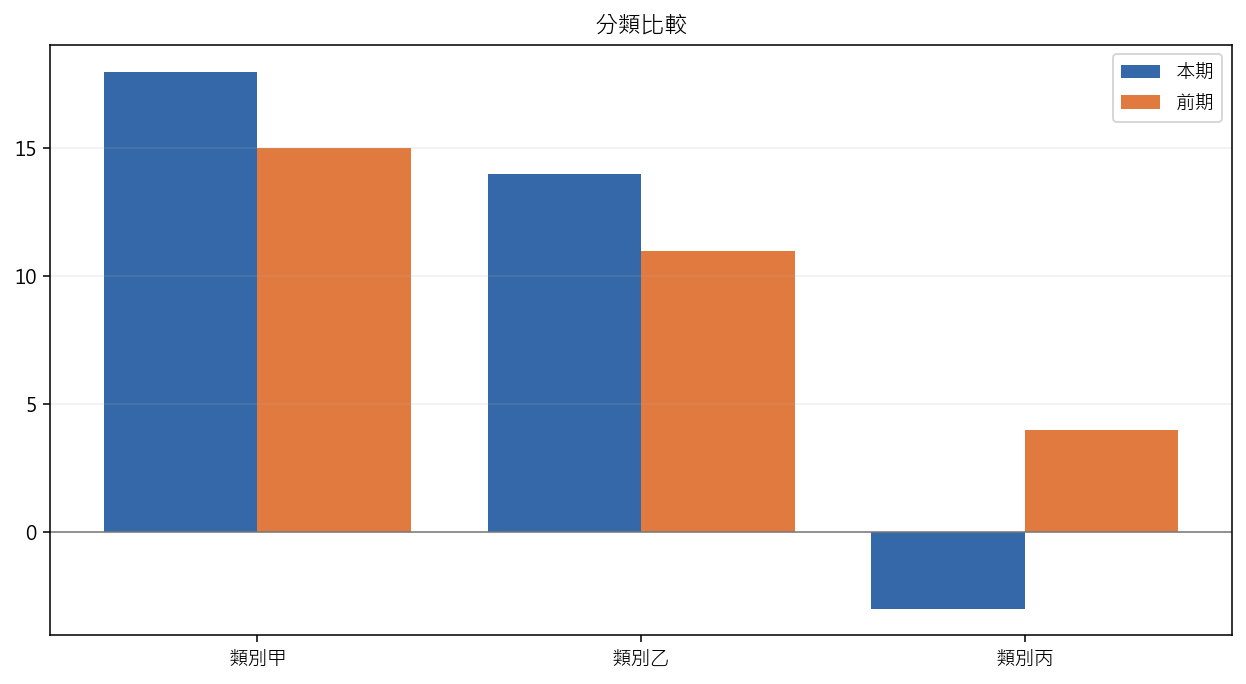

In [4]:
bar_payload = [
    ChartSeries("本期", ["類別甲", "類別乙", "類別丙"], [18, 14, -3]),
    ChartSeries("前期", ["類別甲", "類別乙", "類別丙"], [15, 11, 4]),
]
render_bar(bar_payload, title="分類比較")

## Pie

適合非負、總和大於零的組成比例。

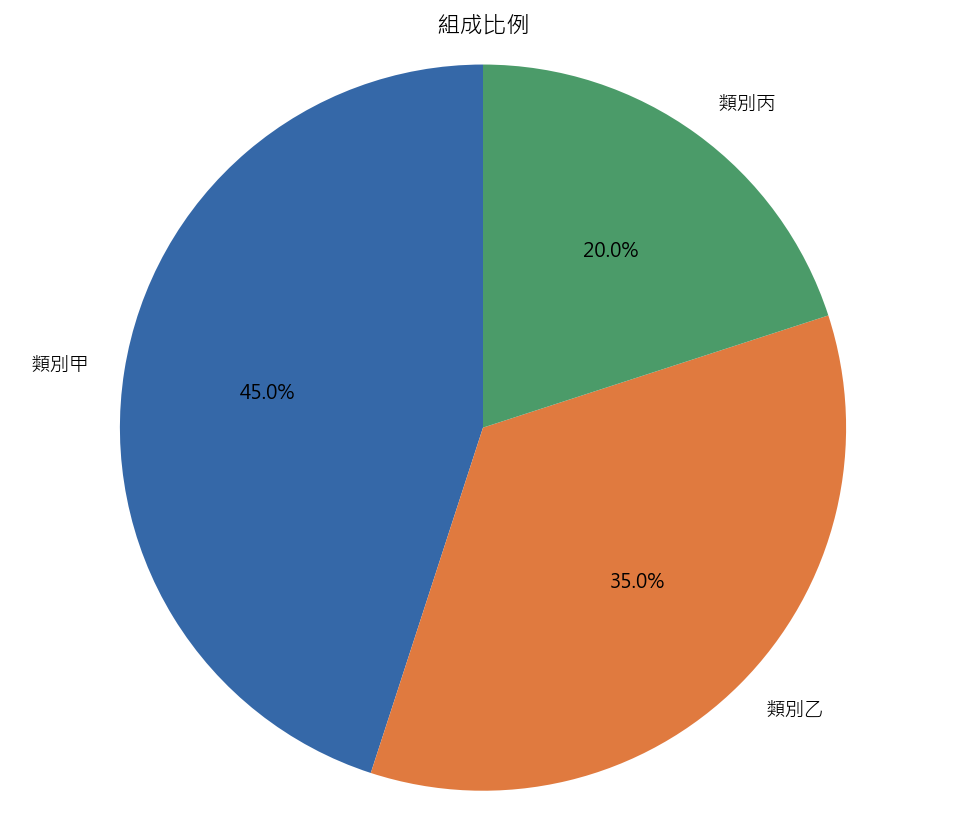

In [5]:
pie_payload = ChartSeries(
    "比例",
    ["類別甲", "類別乙", "類別丙"],
    [45, 35, 20],
)
render_pie(pie_payload, title="組成比例")

## Line

適合有順序的階段或時間趨勢，支援多序列。

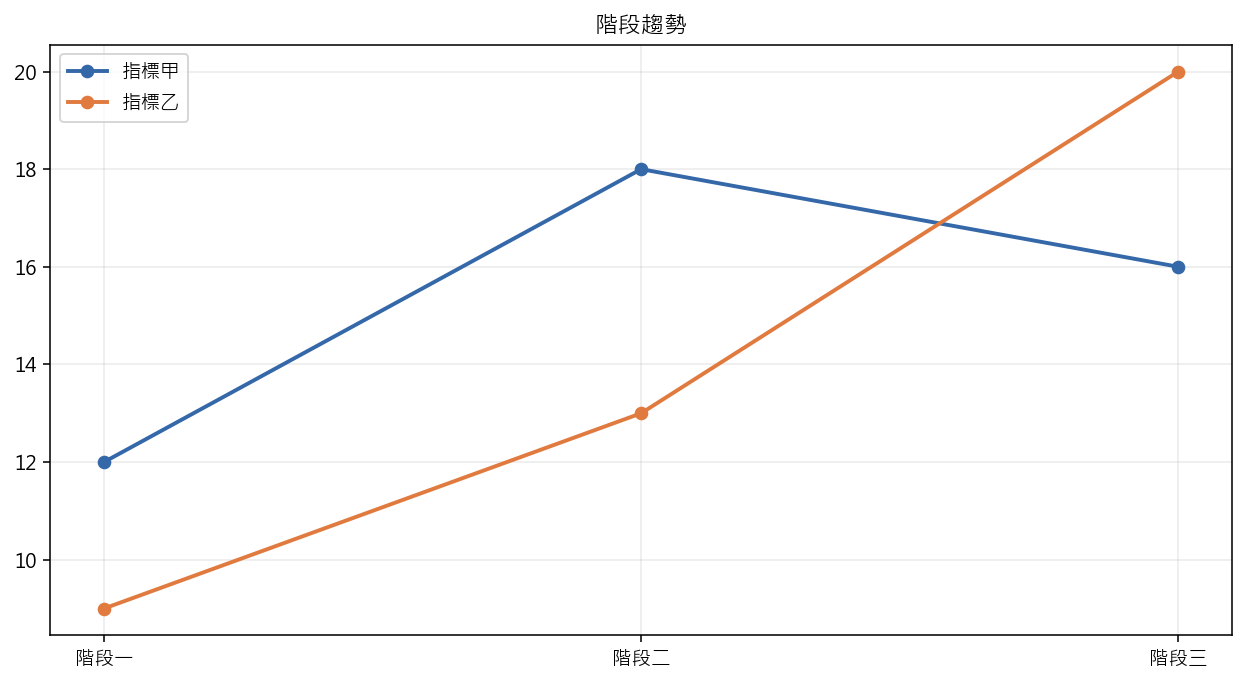

In [6]:
line_payload = [
    ChartSeries("指標甲", ["階段一", "階段二", "階段三"], [12, 18, 16]),
    ChartSeries("指標乙", ["階段一", "階段二", "階段三"], [9, 13, 20]),
]
render_line(line_payload, title="階段趨勢")

## Scatter

適合兩個連續變數的關聯；labels 作為 X 值。

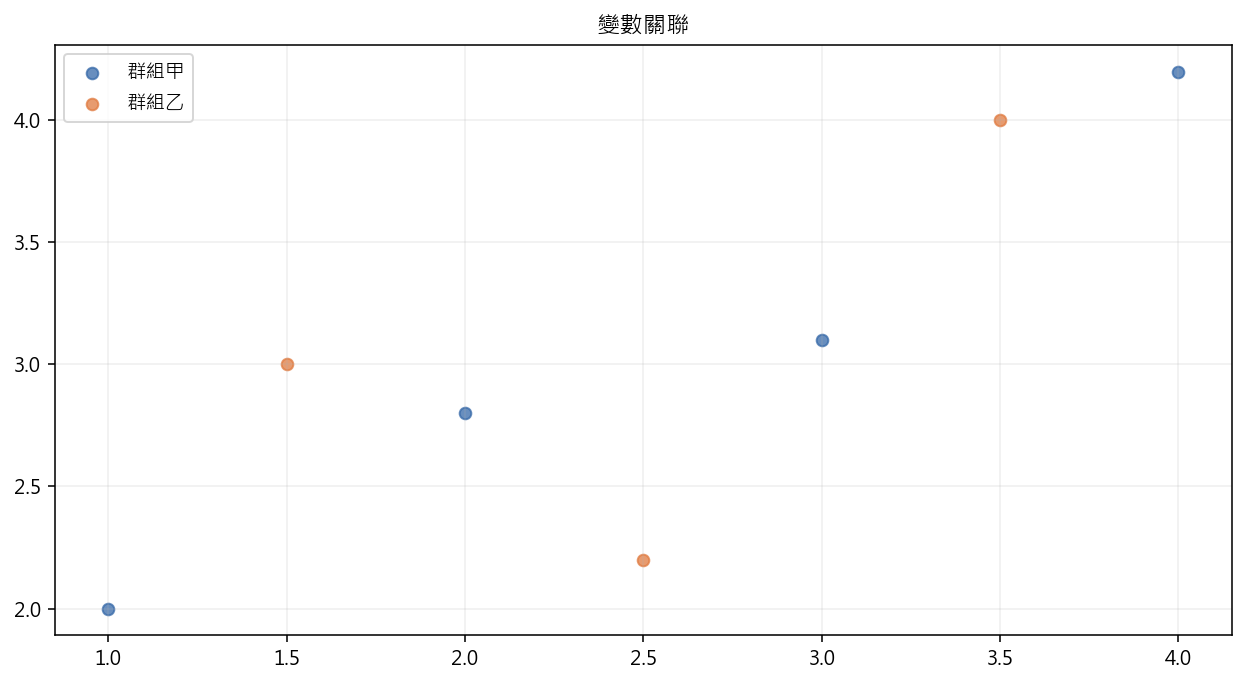

In [7]:
scatter_payload = [
    ChartSeries("群組甲", [1, 2, 3, 4], [2.0, 2.8, 3.1, 4.2]),
    ChartSeries("群組乙", [1.5, 2.5, 3.5], [3.0, 2.2, 4.0]),
]
render_scatter(scatter_payload, title="變數關聯")

## Heatmap

適合二維連續點的密度或權重分布。

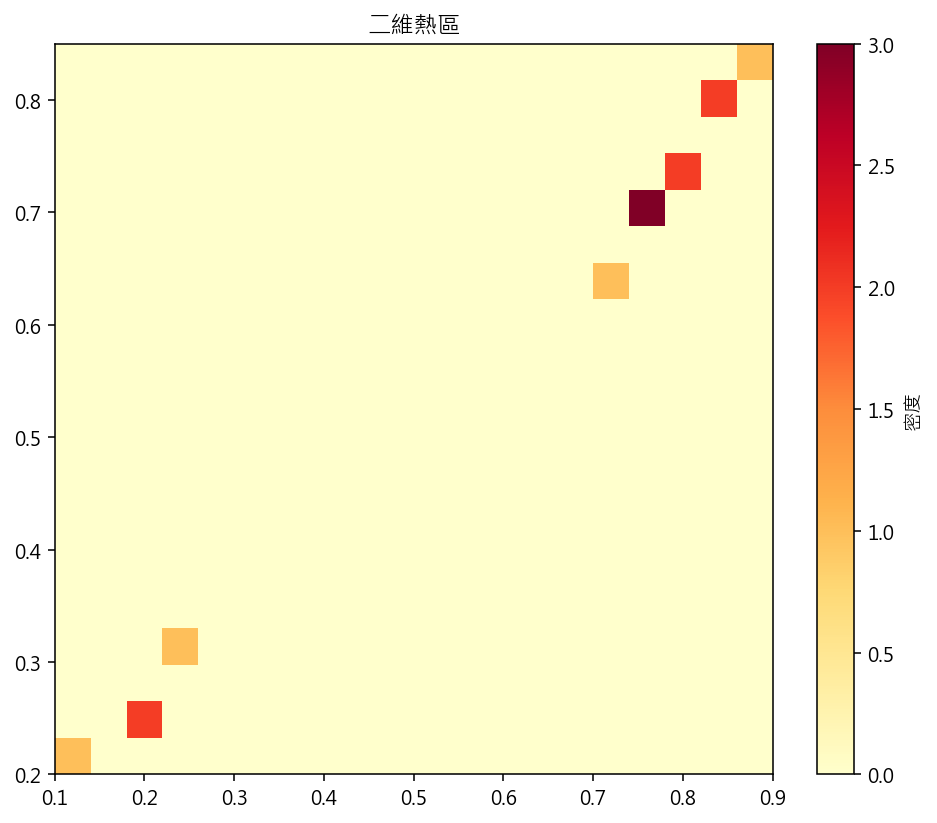

In [8]:
heatmap_payload = HeatmapPoints(
    x=[0.1, 0.2, 0.25, 0.7, 0.75, 0.8, 0.85, 0.9],
    y=[0.2, 0.25, 0.3, 0.65, 0.7, 0.72, 0.8, 0.85],
    weights=[1, 2, 1, 1, 3, 2, 2, 1],
)
render_heatmap(heatmap_payload, title="二維熱區")

## Composite

適合有限的文字、表格與圖表組合；最多四個面板。

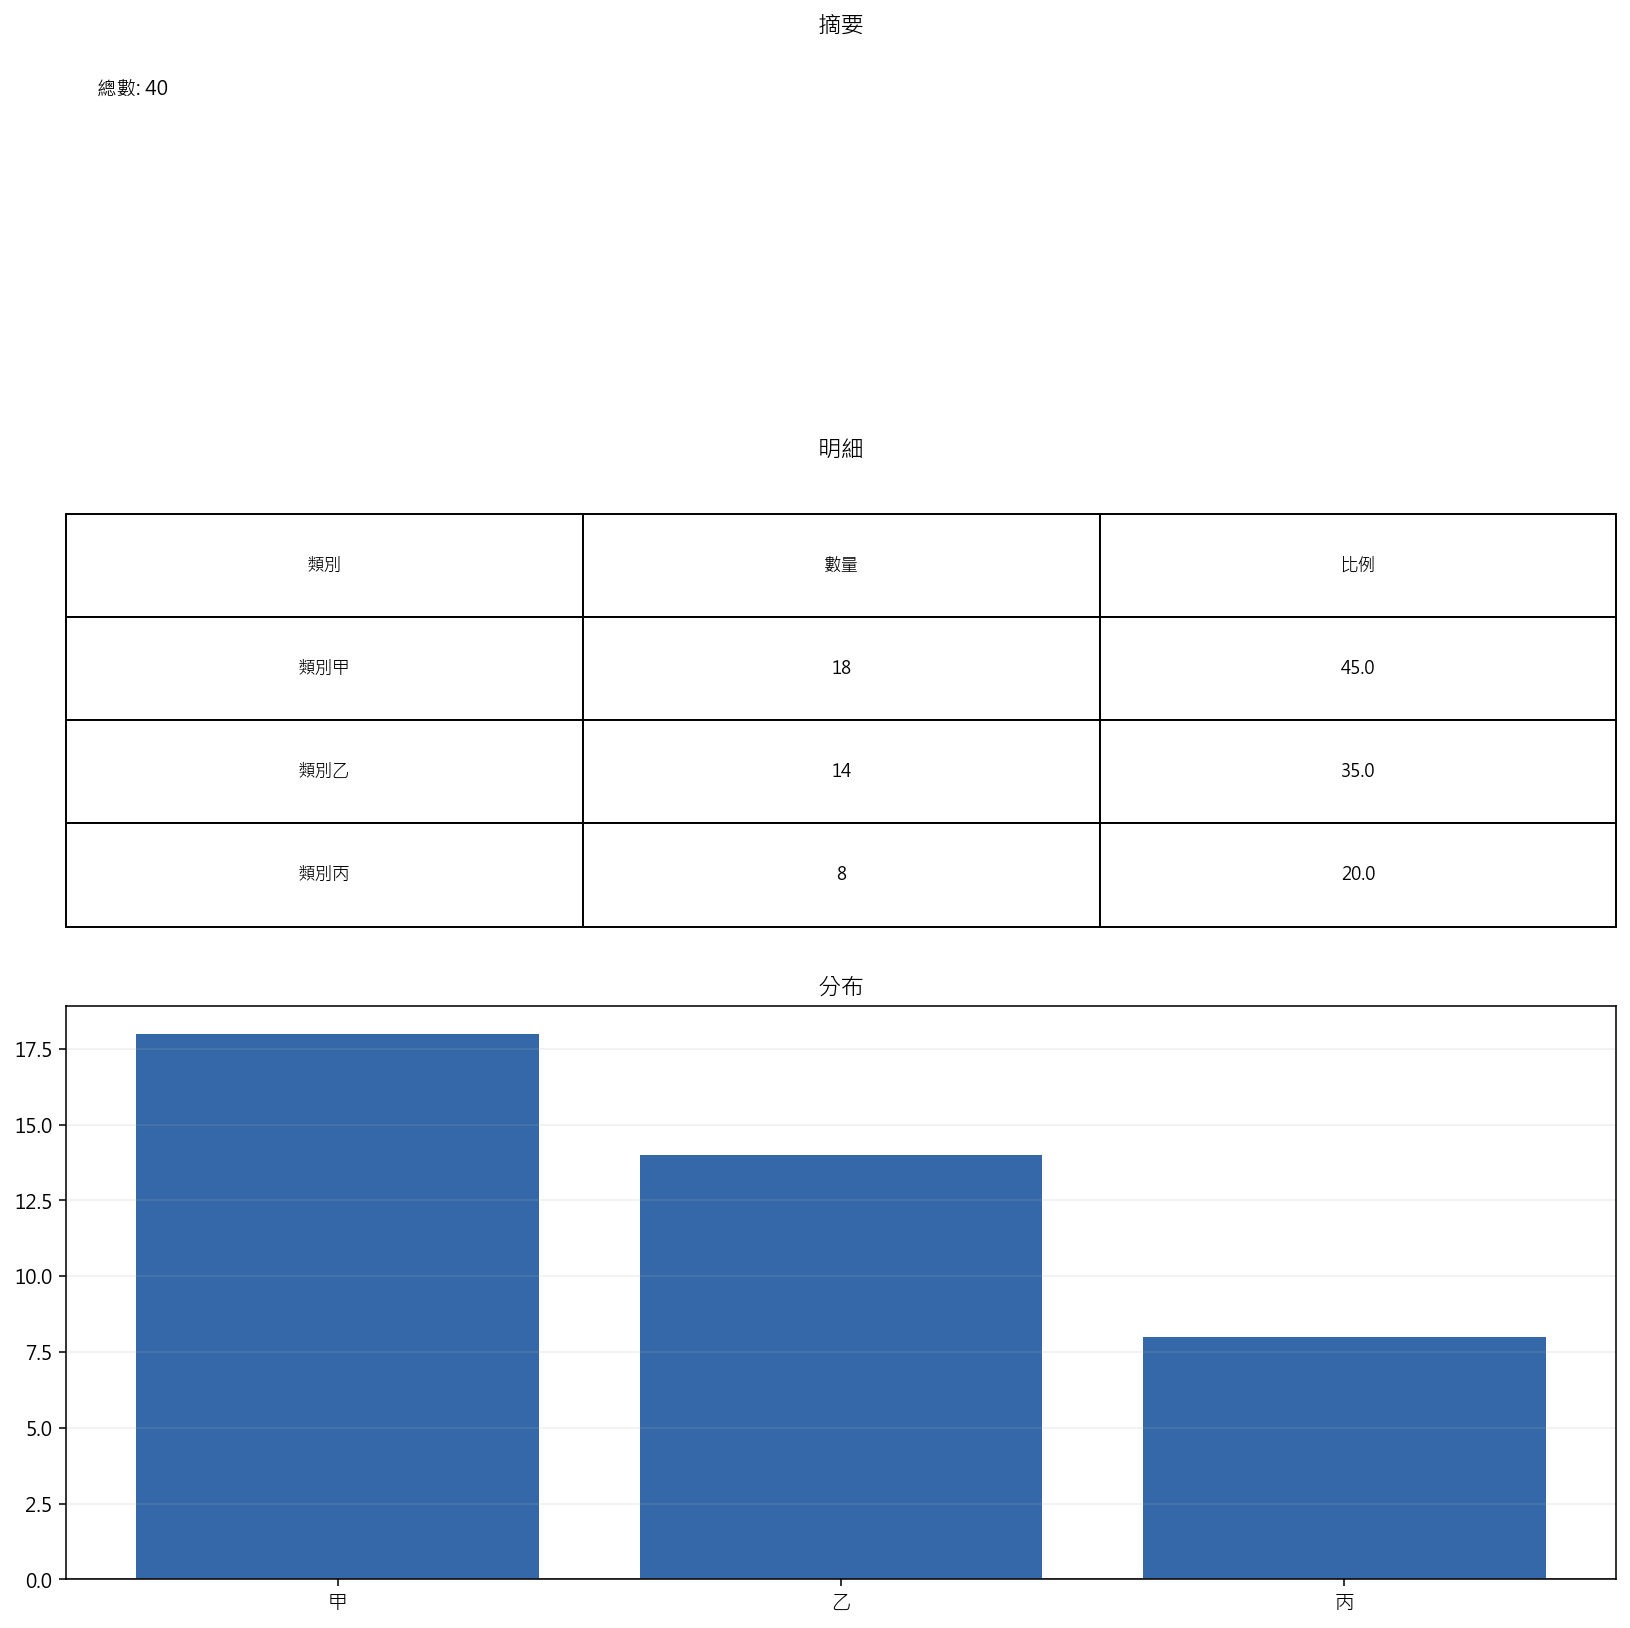

In [9]:
composite_payload = CompositeResult([
    CompositeItem("text", ScalarResult("總數", 40), title="摘要"),
    CompositeItem("table", table_payload, title="明細"),
    CompositeItem("bar", ChartSeries("數量", ["甲", "乙", "丙"], [18, 14, 8]), title="分布"),
])
render_composite(composite_payload)